<h2 style="font-weight:600;color:#4f4a9e">Nigerian Music scraped from Spotify - an analysis</h2>

The K-Means clustering process executes in a three-step process:

The algorithm selects k-number of center points by sampling from the dataset. After this, it loops:
1. It assigns each sample to the nearest centroid.
2. It creates new centroids by taking the mean value of all of the samples assigned to the previous centroids.
3. Then, it calculates the difference between the new and old centroids and repeats until the centroids are stabilized.

<h3 style="font-weight:600;color:white;background:#4f4a9e;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">1 | Preparation</h3>

Start where we finished in the last lesson, with data imported and filtered.

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn import metrics

df = pd.read_csv("../data/nigerian-songs.csv")
df.head()

,name,album,artist,artist_top_genre,release_date,length,popularity,danceability,acousticness,energy,instrumentalness,liveness,loudness,speechiness,tempo,time_signature
0,Sparky,Mandy & The Jungle,Cruel Santino,alternative r&b,2019,144000,48,0.666,0.8510,0.420,0.534000,0.1100,-6.699,0.0829,133.015,5
1,shuga rush,EVERYTHING YOU HEARD IS TRUE,Odunsi (The Engine),afropop,2020,89488,30,0.710,0.0822,0.683,0.000169,0.1010,-5.640,0.3600,129.993,3
2,LITT!,LITT!,AYLØ,indie r&b,2018,207758,40,0.836,0.2720,0.564,0.000537,0.1100,-7.127,0.0424,130.005,4
3,Confident / Feeling Cool,Enjoy Your Life,Lady Donli,nigerian pop,2019,175135,14,0.894,0.7980,0.611,0.000187,0.0964,-4.961,0.1130,111.087,4
4,wanted you,rare.,Odunsi (The Engine),afropop,2018,152049,25,0.702,0.1160,0.833,0.910000,0.3480,-6.044,0.0447,105.115,4


We will focus only on 3 genres. Maybe we can get 3 clusters built!

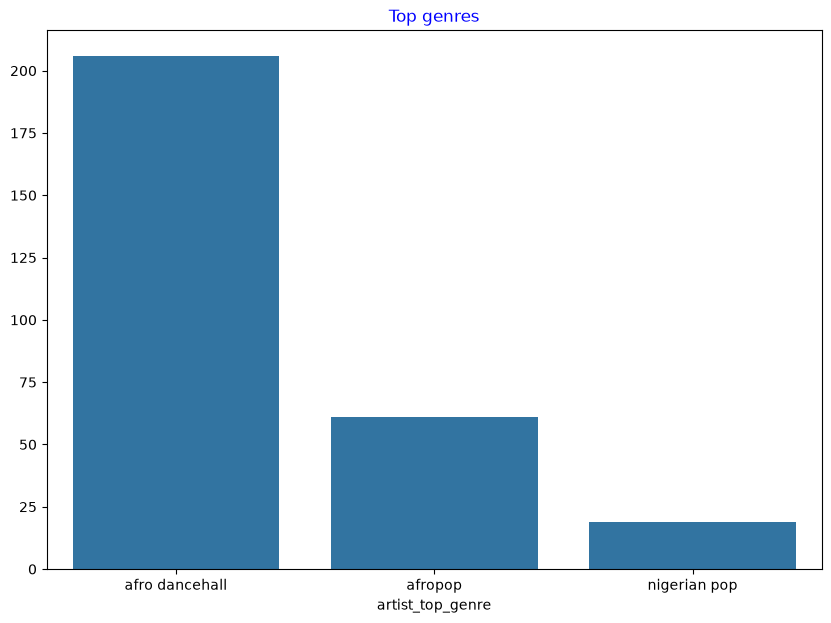

In [8]:
df = df[
    (df["artist_top_genre"] == "afro dancehall")
    | (df["artist_top_genre"] == "afropop")
    | (df["artist_top_genre"] == "nigerian pop")
]
df = df[(df["popularity"] > 0)]
top = df["artist_top_genre"].value_counts()
plt.figure(figsize=(10, 7))
sns.barplot(x=top.index, y=top.values)
plt.xticks(rotation=0)
plt.title("Top genres", color="blue")

plt.show()

Create a `boxplot` for each column:

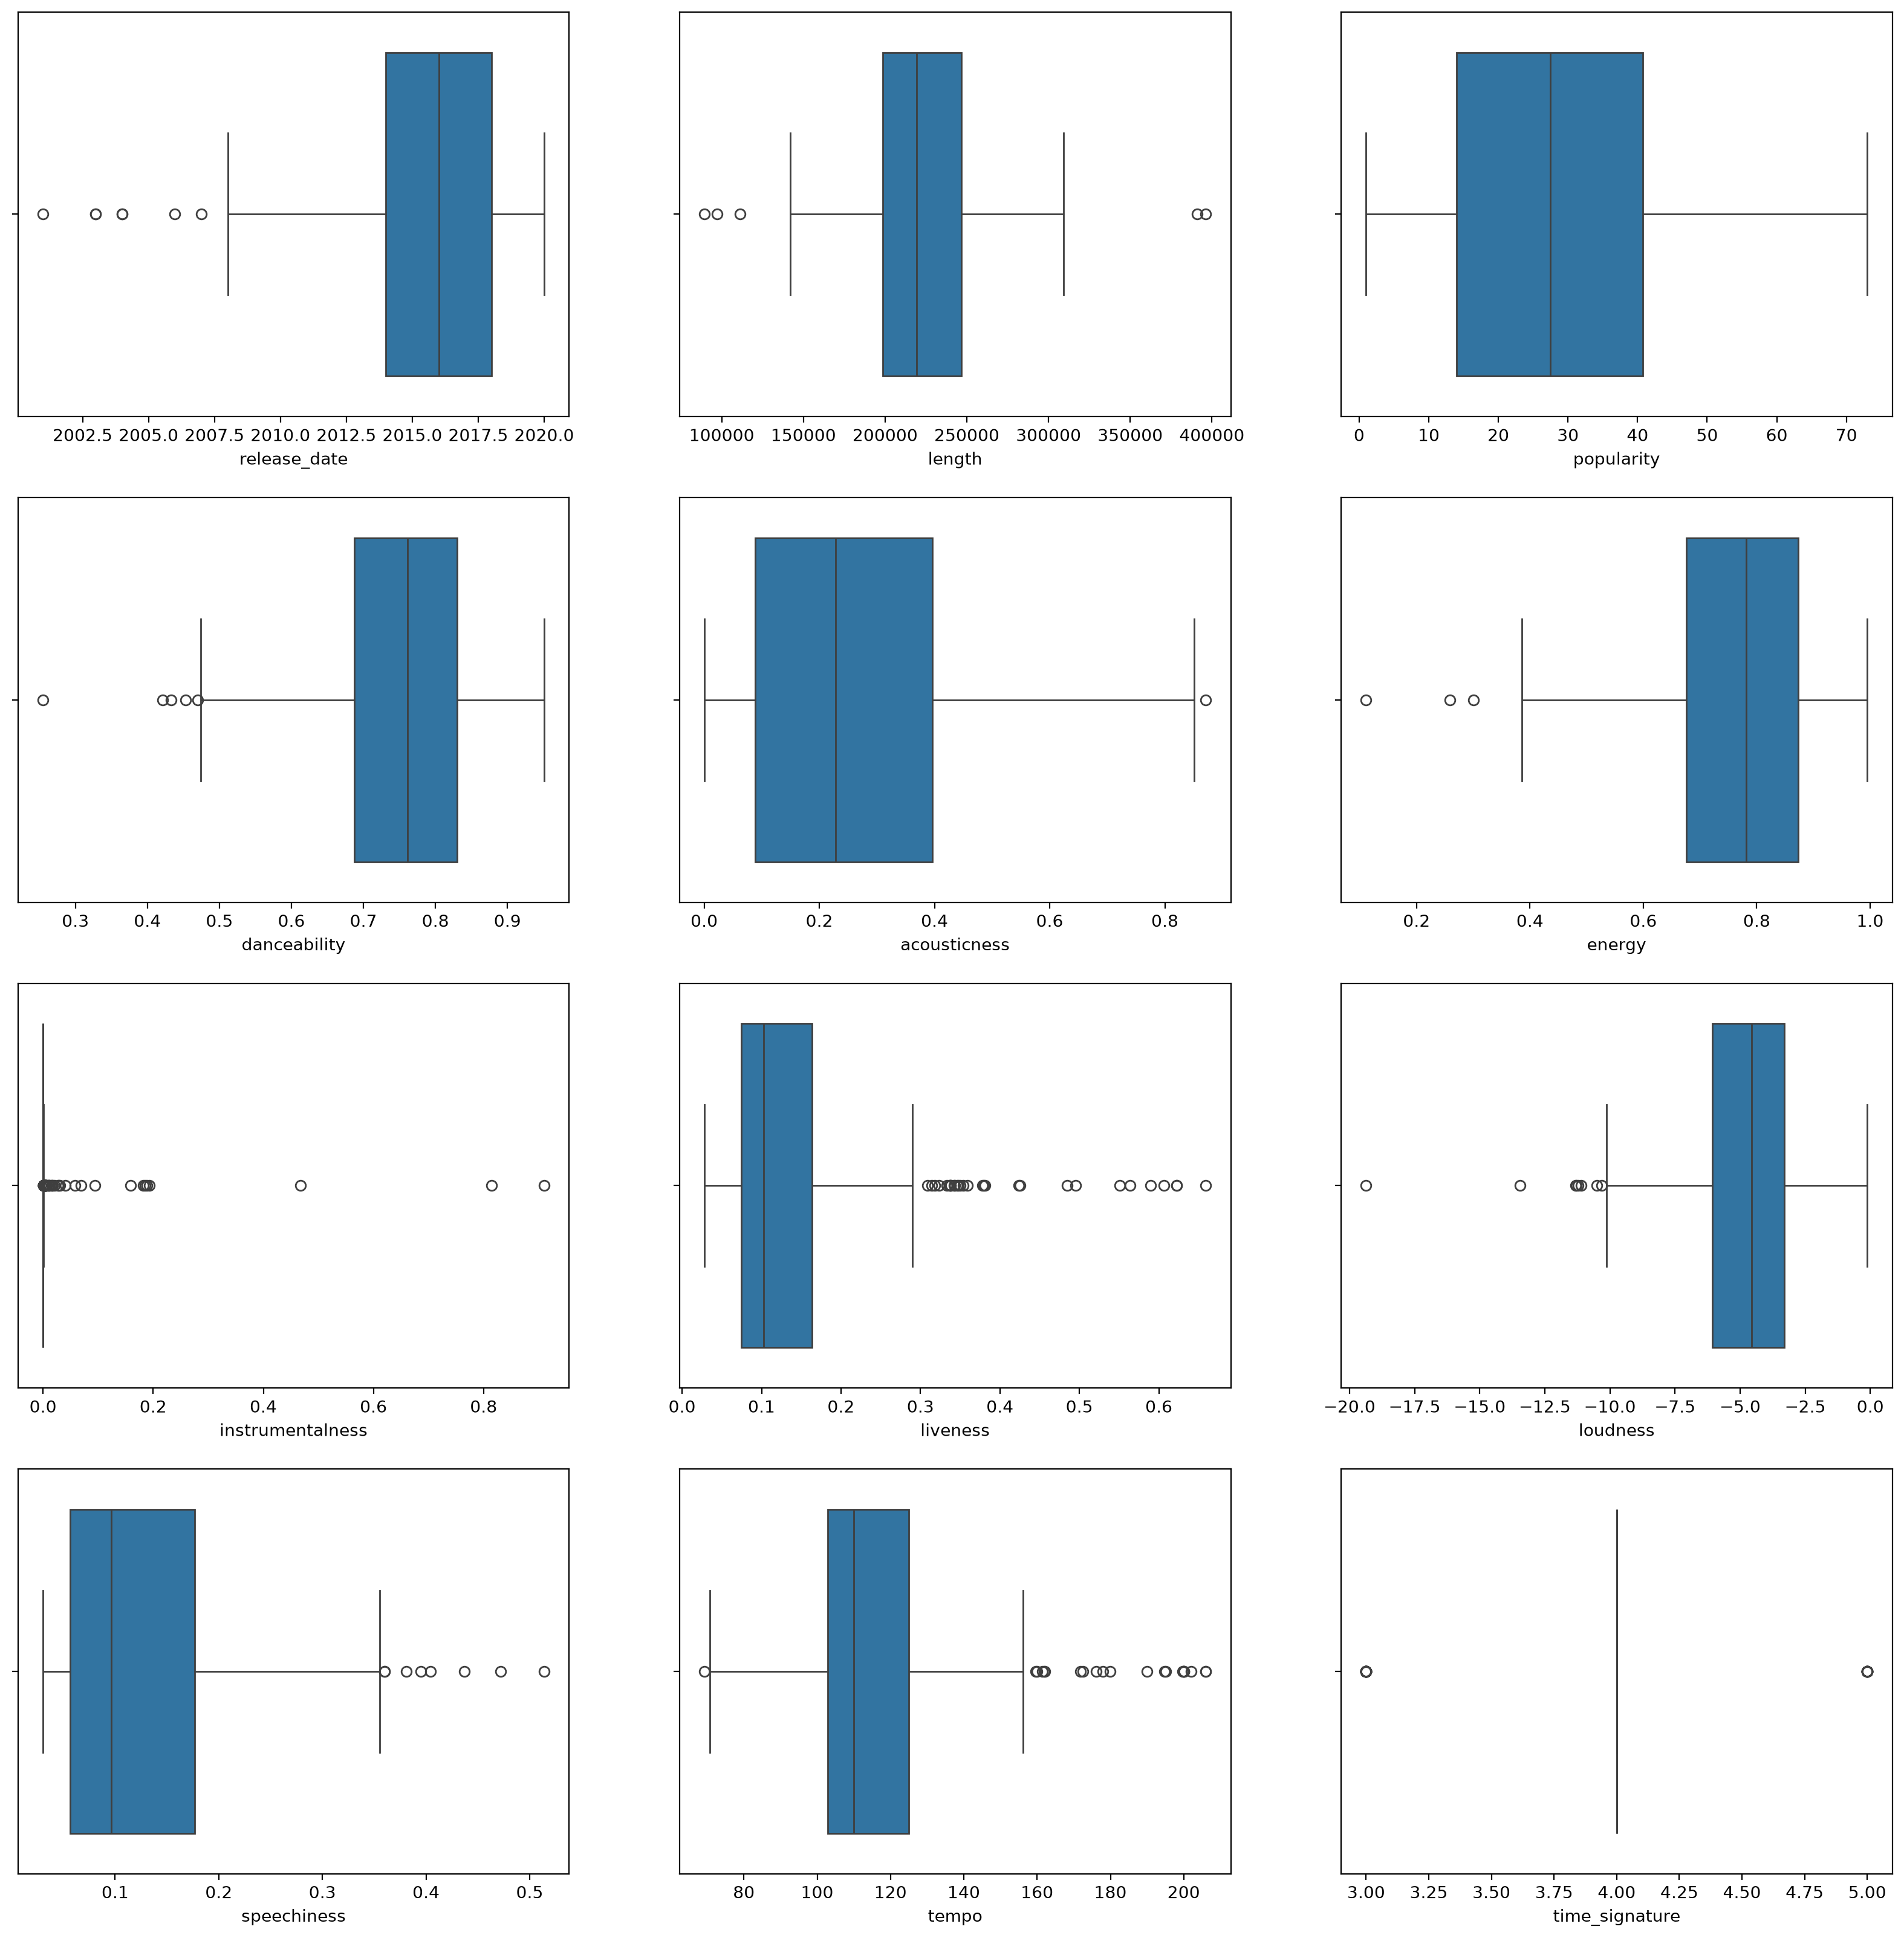

In [9]:
plt.figure(figsize=(20, 20), dpi=200)

idx = df.columns.drop(labels=["name", "album", "artist", "artist_top_genre"])

# Plot a boxplot for each column in a 4x3 grid:b
for index, column in enumerate(idx):
    plt.subplot(4, 3, index + 1)
    sns.boxplot(data=df, x=column)

plt.show()

The data is a little **noisy**. By observing each column as a boxplot, we can see **outliers**. Should we remove them? That would make the data pretty minimal, so leave them as it is.

1. **Choose which columns to use for the clustering exercise.**<br/>
    Pick columns with similar ranges and encode the `artist_top_genre` column as numeric data.

In [10]:
le = LabelEncoder()

X = df.loc[:, ("artist_top_genre", "popularity", "danceability", "acousticness", "loudness", "energy")]
y = df["artist_top_genre"]
X["artist_top_genre"] = le.fit_transform(X["artist_top_genre"])
y = le.transform(y)

In [11]:
X.head()

,artist_top_genre,popularity,danceability,acousticness,loudness,energy
1,1,30,0.710,0.0822,-5.640,0.683
3,2,14,0.894,0.7980,-4.961,0.611
4,1,25,0.702,0.1160,-6.044,0.833
5,2,26,0.803,0.1270,-10.034,0.525
6,2,29,0.818,0.4520,-9.840,0.587


2. **Pick how many clusters to target.**<br/>
Since we deal with only 3 genres, let's try 3:

In [12]:
nclusters = 3
seed = 0

km = KMeans(n_clusters=nclusters, random_state=seed)
km.fit(X)

# Predit the cluster for each data point.
y_cluster_kmeans = km.predict(X)
y_cluster_kmeans

array([2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 1, 2, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 2, 1, 1, 2, 2, 0, 0, 1, 2, 2, 2, 2, 0, 0, 1, 2, 1, 2, 1,
       2, 1, 1, 0, 0, 2, 0, 1, 1, 2, 2, 2, 2, 0, 0, 1, 0, 2, 2, 0, 2, 2,
       0, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 1, 2, 0, 0, 0, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 1,
       0, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 1, 0, 2, 0, 2,
       0, 2, 2, 2, 1, 2, 0, 0, 0, 2, 0, 1, 0, 2, 2, 0, 0, 0, 1, 0, 2, 2,
       2, 0, 0, 1, 0, 2, 0, 0, 0, 0, 2, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 2,
       1, 0, 1, 1, 0, 1, 1, 2, 1, 1, 0, 0, 2, 1, 2, 2, 1, 2, 2, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 2, 1, 0, 1, 2, 1, 1, 2, 2, 2, 0, 0, 0, 0, 0, 1,
       2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 0, 1, 0, 0, 0, 1, 2, 2, 2,
       0, 0, 1, 1, 0, 0, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 0, 0, 2, 2, 2,
       0, 2, 0, 2, 0, 0, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 2, 0, 0, 0, 2, 0],
      dtype=int32)

<h3 style="font-weight:600;color:white;background:#4f4a9e;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">2 | Silhouette Score</h3>

Use the above array with the predictions for the clusters of each row in the data frame, to calculate a `silhouette score`:
- **score near 1** : the cluster is dense and well-separated from the rest.
- **score near 0** : overlapping clusters with samples very close to the decision boundary.

In [15]:
score = metrics.silhouette_score(X, y_cluster_kmeans)
print(f"{score:.2f}")

0.55


The score of **0.55** is right in the middle, indicating t*he data is not particularly well-suited to this type of clustering*.

<h3 style="font-weight:600;color:white;background:#4f4a9e;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">3 | Build a Model</h3>

1️⃣ We perform the clustering process for a range of 1 to 10 clusters.<br/>
2️⃣ The **k-means++** optimization initializes the centroids to be distant from each other(better than random initialization).<br/>
3️⃣ The **random_state** determines random number generation for centroid initialization.<br/>
4️⃣ **Inertia** is a measure of how internally coherent clusters are. KMeans tries to minimize inertia when choosing centroids.<br/>
5️⃣ **WCSS** : within-cluster sums of squares is the average squared distance of all points within a cluster, from their centroid.

In [17]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

<h4 style="font-weight:600;color:white;background:#4f4a9e;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">3.1 | The Elbow Method</h4>

The Elbow method helps us decide the appropriate number of clusters we should choose. The chart below shows that the **bend** in the elbow, indicating the optimum number of clusters, is 3!

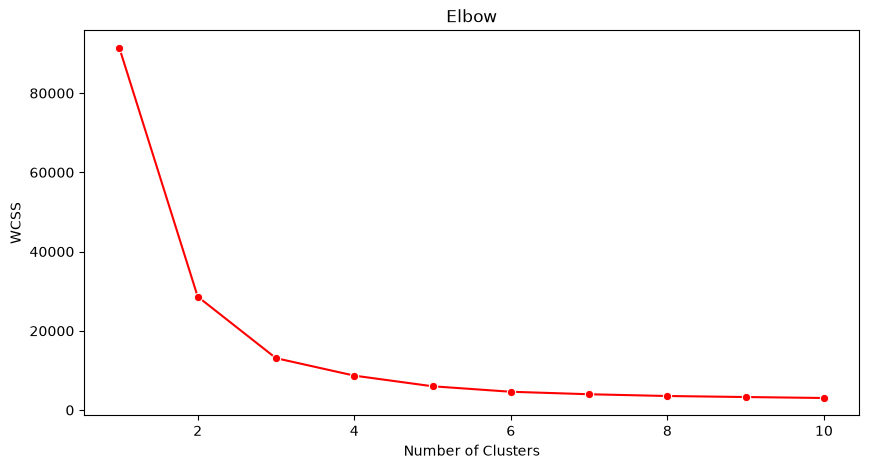

In [20]:
plt.figure(figsize=(10, 5))

sns.lineplot(x=range(1, 11), y=wcss, marker="o", color="red")
plt.title("Elbow")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

<h3 style="font-weight:600;color:white;background:#4f4a9e;padding:25px;margin:20;text-align:left;display:fill;border-radius:10px 0 0 10px;text-transform:uppercase;">4 | Display the Clusters</h3>

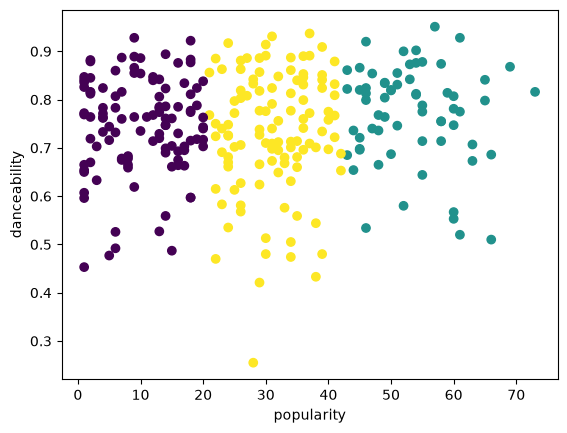

In [22]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
labels = kmeans.predict(X)

plt.scatter(df["popularity"], df["danceability"], c=labels)
plt.xlabel("popularity")
plt.ylabel("danceability")

plt.show()

**Check the model's accuracy:**

In [26]:
labels = kmeans.labels_
correct_labels = sum(y == labels)

print(f"Result: {correct_labels} out of {y.size} samples were correctly labeled.")
print(f"Accuracy Score: {correct_labels/y.size:.2f}")

Result: 111 out of 286 samples were correctly labeled.
Accuracy Score: 0.39


The accuracy of the model is not good at all. From the shape of the clusters we see that:
- the data is too imbalanced
- they are not correlated
- there's too much variance between the columns to cluster well.